In [ ]:
# CREATE CONDA ENVIRONMENT AND INSTALL KERNEL
#module load Miniconda3/23.10.0-1
#conda create --prefix /gpfs/commons/groups/landau_lab/tprieto/conda/classifier-env \
#    python=3.10 pandas numpy matplotlib seaborn scikit-learn xgboost -y
# conda activate /gpfs/commons/groups/landau_lab/tprieto/conda/classifier-env
#python -c "import pandas, numpy, matplotlib, seaborn, sklearn, xgboost; print('OK')"
#conda install ipykernel -y

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import gc

In [ ]:
#list(pd.read_csv("feat/eso29-feat.table", sep="\t", low_memory=False,).columns)

In [23]:
is_stringent = True
label_col = 'LR_class_stringent' if is_stringent else 'LR_class'
cls_cols = ["CHROM", "POS", "REF", "ALT", "QUAL", "TRANSITION", 'PTA_20bpCONTEXTwithREF',
 'PTA_GENEBODY',
 'PTA_STRAND',
 'PTA_SIMPLEREPEAT',
 'PTA_REPLISEQ',
 #'PTA_REDI',
 'PTA_MINMAD',
 'PTA_MAXVAF',
 'PTA_MAXALT',
 'PTA_RNACOV',
 'PTA_RNAALT',
 #'PTA_ADO200kbinterval',
 'PTA_ADOResidualLoessPseudobulk',
 'PTA_ADOmaxbinompvalue', label_col]
cl_dict = {'fp': 1, 'tp': 0}

In [46]:

#eso29 = pd.read_csv("/gpfs/commons/groups/landau_lab/ResolveOME/StartDir/eso29/manual_collate/sequoia/myselectedvars.snvswithsingletons.LR.4classifier.table", sep="\t", low_memory=False, usecols=cls_cols)
#cu01 = pd.read_csv("/gpfs/commons/groups/landau_lab/ResolveOME/StartDir/cu01/manual_collate/sequoia/myselectedvars.snvswithsingletons.LR.4classifier.table", sep="\t", low_memory=False, usecols=cls_cols)
#cu02 = pd.read_csv("/gpfs/commons/groups/landau_lab/ResolveOME/StartDir/cu02/manual_collate/sequoia/myselectedvars.snvswithsingletons.LR.4classifier.table", sep="\t", low_memory=False, usecols=cls_cols)
#cu03 = pd.read_csv("/gpfs/commons/groups/landau_lab/ResolveOME/StartDir/cu03/manual_collate/sequoia/myselectedvars.snvswithsingletons.LR.4classifier.table", sep="\t", low_memory=False, usecols=cls_cols)
cu08 = pd.read_csv("/gpfs/commons/groups/landau_lab/ResolveOME/StartDir/cu08/manual_collate/sequoia/myselectedvars.snvswithsingletons.LR.4classifier.table", sep="\t", low_memory=False, usecols=cls_cols)

# Add source column to each dataframe
#eso29['source'] = 'eso29'
#cu01['source'] = 'cu01'
#cu02['source'] = 'cu02'
#cu03['source'] = 'cu03'
cu08['source'] = 'cu08'

# Concatenate all dataframes
del data
#data = pd.concat([eso29, cu01, cu02, cu03], ignore_index=True)
data = pd.concat([cu08], ignore_index=True)
#data = pd.concat([cu01, cu02, cu03, cu08, eso29], ignore_index=True)


#data = eso29
data.head()
data.shape


(1378522, 20)

In [47]:
data['LR_class_stringent'].value_counts()


LR_class_stringent
uncertain    52224
fp           12447
tp            6114
Name: count, dtype: int64

In [48]:
# remove uncertain
data = data[data[label_col].notna() & (data[label_col] != 'uncertain')]

In [49]:
data['LR_class_stringent'].value_counts(normalize=True)


LR_class_stringent
fp    0.6706
tp    0.3294
Name: proportion, dtype: float64

In [51]:
data.shape

(18561, 20)

In [52]:
data['PTA_SIMPLEREPEAT'] = data['PTA_SIMPLEREPEAT'].astype(str).str.split(',').str[0].astype(float).astype('int64')


In [53]:
def plot_mutation_signature(fp_sig, title='False Positive Mutation Signature', save_path=None):
    """
    Create a mutation signature plot showing trinucleotide context frequencies.
    
    Args:
        fp_sig: pandas Series containing mutation frequencies indexed by trinucleotide context
        title: str, plot title (default: 'False Positive Mutation Signature')
        save_path: str, optional file path to save plot as PDF
    """
    # Create figure
    plt.figure(figsize=(18, 5))

    # Define mutation type order and colors
    mutation_order = ['C>A', 'C>G', 'C>T', 'T>A', 'T>C', 'T>G']
    mutation_colors = ['#2EBAED', '#000000', '#DE1C14', '#D4D2D2', '#ADCC54', '#F4A460']

    # Create custom sort key function
    def sort_key(context):
        for i, mut in enumerate(mutation_order):
            if mut in context:
                return (i, context)
        return (len(mutation_order), context)

    # Sort index according to mutation type order
    sorted_index = sorted(fp_sig.index, key=sort_key)
    sorted_values = fp_sig[sorted_index]

    # Create color list matching the sorted contexts
    colors = []
    for context in sorted_index:
        for i, mut in enumerate(mutation_order):
            if mut in context:
                colors.append(mutation_colors[i])
                break

    # Plot bars with colors
    plt.bar(range(len(sorted_values)), sorted_values, color=colors)

    # Customize x-axis
    plt.xticks(range(len(sorted_values)), sorted_index, rotation=90)

    # Add labels and title
    plt.xlabel('Trinucleotide Context')
    plt.ylabel('Frequency')
    plt.title(title)

    # Adjust layout
    plt.tight_layout()
    
    # Save as PDF if path provided
    if save_path:
        plt.savefig(save_path, format='pdf', bbox_inches='tight')


In [54]:
def trinucleotide_context(row):
    # Get the trinucleotide context and alt allele
    ref = row['PTA_20bpCONTEXTwithREF'][9:12]  # Get central trinucleotide
    alt = row['ALT']
    center_base = ref[1]  # The mutated base
    
    def reverse_complement(seq):
        return seq[::-1].translate(str.maketrans('ACGT', 'TGCA'))
    
    # If reference base is G or A, take reverse complement
    # This ensures we only deal with C>N and T>N mutations
    if center_base in ['G', 'A']:
        ref = reverse_complement(ref)
        alt = reverse_complement(alt)
        
    # Format as upstream[REF>ALT]downstream
    return f"{ref[0]}[{ref[1]}>{alt}]{ref[2]}"


In [55]:
def prepare_data(data: pd.DataFrame, stringent_label: bool = False) -> pd.DataFrame: 
    """
    Prepare dataframe for machine learning by extracting sequence context features
    and converting object columns to category dtype.
    
    Args:
        data (pd.DataFrame): Input dataframe containing variant data
        
    Returns:
        pd.DataFrame: Processed dataframe with sequence context features
    """
    class_col = 'LR_class_stringent' if stringent_label else 'LR_class'
    # Select relevant columns
    cols = cls_cols # ["CHROM", "POS", "REF", "ALT", "QUAL", "TRANSITION", "PTA_REPLISEQ", "PTA_STRAND", "PTA_GENEBODY", "PTA_20bpCONTEXTwithREF", "PTA_ALLELICIMBALANCE", "PTA_SIMPLEREPEAT", class_col]
    df = data[cols].copy()
    df = df[df[class_col] != 'uncertain']
    
    # Extract sequence context features
    #df['TRINUCLEOTIDE_CONTEXT'] = df['PTA_20bpCONTEXTwithREF'].str[9:12]
    df['TRINUCLEOTIDE_CONTEXT'] = df.apply(trinucleotide_context, axis=1)
    df['FIVE_PRIME_CONTEXT'] = df['PTA_20bpCONTEXTwithREF'].str[:10]
    df['THREE_PRIME_CONTEXT'] = df['PTA_20bpCONTEXTwithREF'].str[-10:]
    df.drop(columns=['PTA_20bpCONTEXTwithREF'], inplace=True)
    df['PTA_SIMPLEREPEAT'] = df['PTA_SIMPLEREPEAT'].astype(str).str.split(',').str[0].str.split('.').str[0].replace('nan', 0).astype('int64')
    df['PTA_GENEBODY'] = df['PTA_GENEBODY'].astype(str).str.split(',').str[0].astype(float).astype('int64')
    # Split context sequences into individual positions
    for i in range(10):
        df[f'FIVE_PRIME_{i+1}'] = df['FIVE_PRIME_CONTEXT'].str[i]
        df[f'THREE_PRIME_{i+1}'] = df['THREE_PRIME_CONTEXT'].str[i]
    
    # Drop original context columns
    df.drop(columns=['FIVE_PRIME_CONTEXT', 'THREE_PRIME_CONTEXT', "CHROM", "POS", "REF", "ALT",], inplace=True)
    
    # Convert object columns to category dtype
    object_columns = df.select_dtypes(include=['object']).columns
    df[object_columns] = df[object_columns].astype('category')
    
    return df


In [56]:
# I think I can create sub and do not overwrite data
sub = prepare_data(data, is_stringent)
sub.head()
sub.shape

(18561, 35)

In [57]:
#del data
#del cu01
#del cu02
#del cu03
#del eso29
#del cu08
gc.collect()


137

In [58]:
sub.dtypes

QUAL                               float64
TRANSITION                           int64
PTA_GENEBODY                         int64
PTA_STRAND                        category
PTA_SIMPLEREPEAT                     int64
PTA_REPLISEQ                       float64
PTA_MINMAD                         float64
PTA_MAXVAF                           int64
PTA_MAXALT                           int64
PTA_RNACOV                         float64
PTA_RNAALT                           int64
PTA_ADOResidualLoessPseudobulk     float64
PTA_ADOmaxbinompvalue              float64
LR_class_stringent                category
TRINUCLEOTIDE_CONTEXT             category
FIVE_PRIME_1                      category
THREE_PRIME_1                     category
FIVE_PRIME_2                      category
THREE_PRIME_2                     category
FIVE_PRIME_3                      category
THREE_PRIME_3                     category
FIVE_PRIME_4                      category
THREE_PRIME_4                     category
FIVE_PRIME_

In [59]:
# Check each column's data types and any mixed types
for col in sub.columns:
    # Get unique types in the column
    types = sub[col].apply(type).unique()
    if len(types) > 1:
        print(f"\nColumn {col} has mixed types:")
        print(types)
        # Show some example values
        print("\nExample values:")
        print(sub[col].head())


In [ ]:
#sub['TRINUCLEOTIDE_CONTEXT'].value_counts().sort_index().to_csv('trinuc_context_counts.tsv',sep='\t')

In [ ]:
#sub[sub['LR_class_stringent'] == 'fp']['TRINUCLEOTIDE_CONTEXT'].value_counts().sort_index().to_csv('train_fp_trinuc_context_counts.tsv',sep='\t')
#sub[sub['LR_class_stringent'] == 'tp']['TRINUCLEOTIDE_CONTEXT'].value_counts().sort_index().to_csv('train_tp_trinuc_context_counts.tsv',sep='\t')

In [60]:
fp_sig = sub[sub['LR_class_stringent'] == 'fp']['TRINUCLEOTIDE_CONTEXT'].value_counts(normalize=True).sort_index()


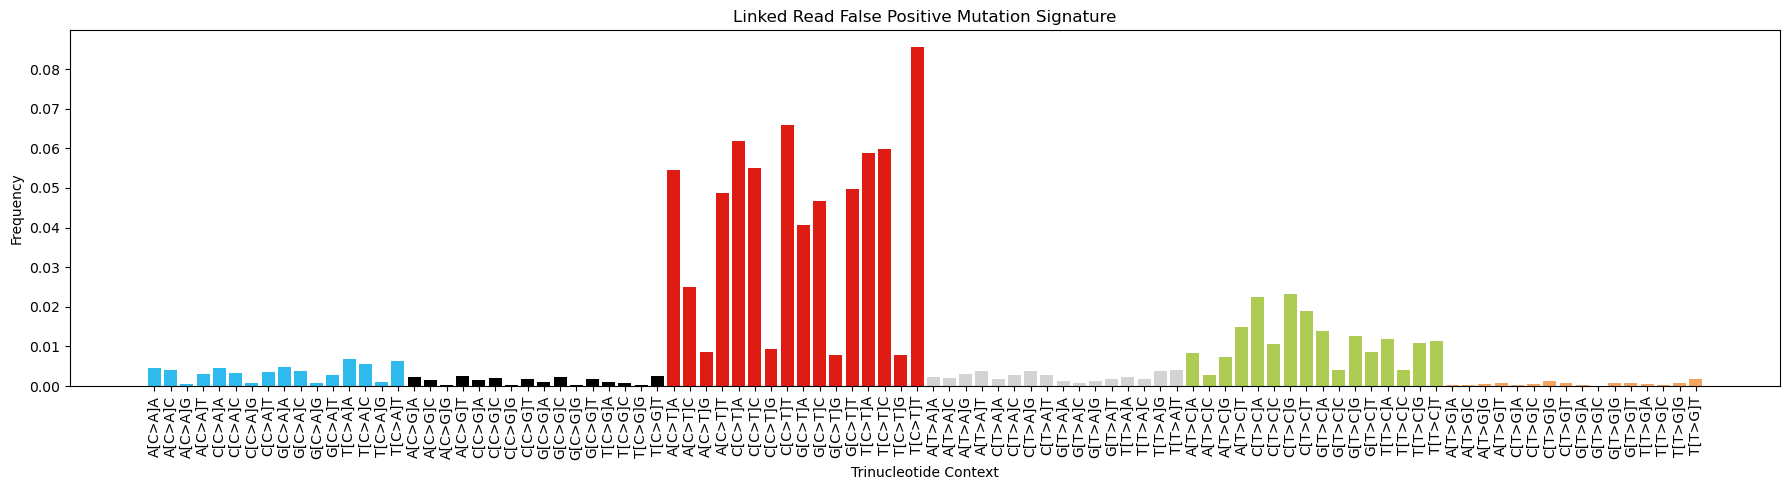

In [61]:
# Create signature plot for false positives
plt.figure(figsize=(18, 5))

# Define mutation type order and colors
mutation_order = ['C>A', 'C>G', 'C>T', 'T>A', 'T>C', 'T>G']
mutation_colors = ['#2EBAED', '#000000', '#DE1C14', '#D4D2D2', '#ADCC54', '#F4A460']

# Create custom sort key function
def sort_key(context):
    for i, mut in enumerate(mutation_order):
        if mut in context:
            return (i, context)
    return (len(mutation_order), context)

# Sort index according to mutation type order
sorted_index = sorted(fp_sig.index, key=sort_key)
sorted_values = fp_sig[sorted_index]

# Create color list matching the sorted contexts
colors = []
for context in sorted_index:
    for i, mut in enumerate(mutation_order):
        if mut in context:
            colors.append(mutation_colors[i])
            break

# Plot bars with colors
plt.bar(range(len(sorted_values)), sorted_values, color=colors)

# Customize x-axis
plt.xticks(range(len(sorted_values)), sorted_index, rotation=90)

# Add labels and title
plt.xlabel('Trinucleotide Context')
plt.ylabel('Frequency')
plt.title('Linked Read False Positive Mutation Signature')

# Adjust layout
plt.tight_layout()
#plt.savefig('lr_fp_sig.pdf', format='pdf', bbox_inches='tight')

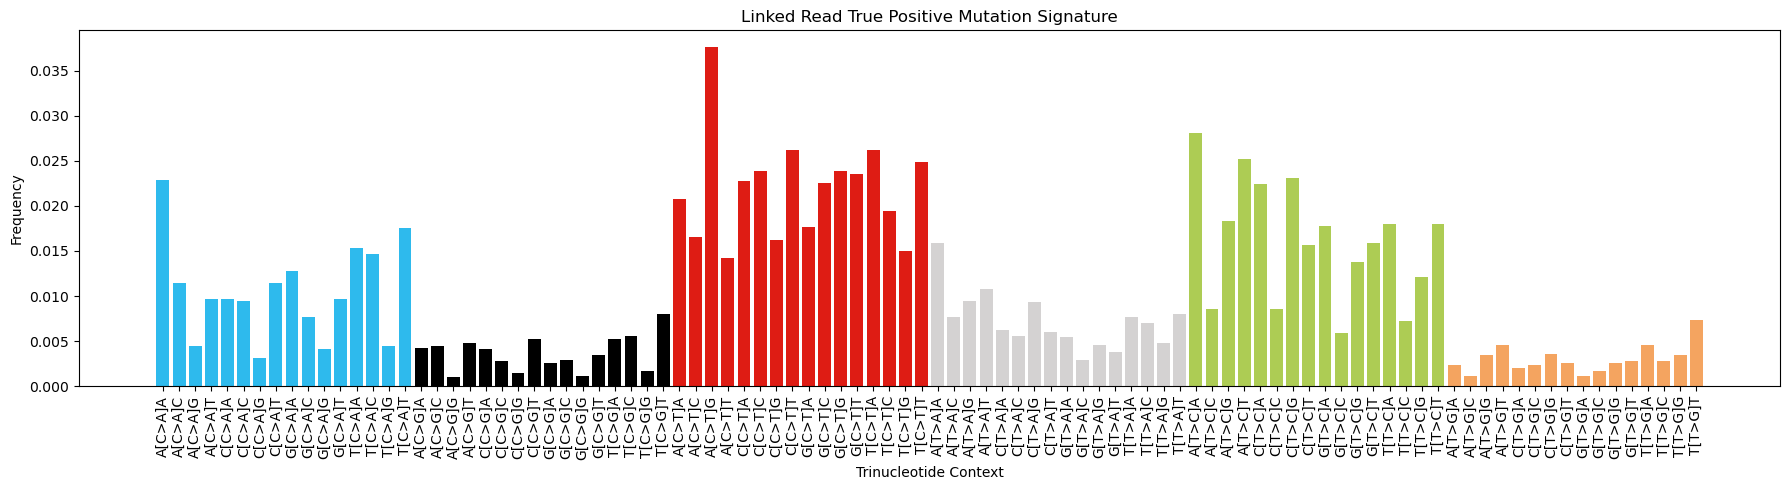

In [62]:
tp_sig = sub[sub['LR_class_stringent'] == 'tp']['TRINUCLEOTIDE_CONTEXT'].value_counts(normalize=True).sort_index()

# Create signature plot for false positives
plt.figure(figsize=(18, 5))

# Define mutation type order and colors
mutation_order = ['C>A', 'C>G', 'C>T', 'T>A', 'T>C', 'T>G']
mutation_colors = ['#2EBAED', '#000000', '#DE1C14', '#D4D2D2', '#ADCC54', '#F4A460']

# Create custom sort key function
def sort_key(context):
    for i, mut in enumerate(mutation_order):
        if mut in context:
            return (i, context)
    return (len(mutation_order), context)

# Sort index according to mutation type order
sorted_index = sorted(tp_sig.index, key=sort_key)
sorted_values = tp_sig[sorted_index]

# Create color list matching the sorted contexts
colors = []
for context in sorted_index:
    for i, mut in enumerate(mutation_order):
        if mut in context:
            colors.append(mutation_colors[i])
            break

# Plot bars with colors
plt.bar(range(len(sorted_values)), sorted_values, color=colors)

# Customize x-axis
plt.xticks(range(len(sorted_values)), sorted_index, rotation=90)

# Add labels and title
plt.xlabel('Trinucleotide Context')
plt.ylabel('Frequency')
plt.title('Linked Read True Positive Mutation Signature')

# Adjust layout
plt.tight_layout()
#plt.savefig('lr_tp_sig.pdf', format='pdf', bbox_inches='tight')


In [63]:
sub[label_col].value_counts()


LR_class_stringent
fp    12447
tp     6114
Name: count, dtype: int64

In [64]:
sub.isna().sum()[lambda x: x > 0]

PTA_RNACOV                        11970
PTA_ADOResidualLoessPseudobulk       11
PTA_ADOmaxbinompvalue             18561
dtype: int64

/gpfs/commons/groups/landau_lab/tprieto/conda/classifier-env/lib/python3.10/site-packages/sklearn/utils/extmath.py:1144: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
/gpfs/commons/groups/landau_lab/tprieto/conda/classifier-env/lib/python3.10/site-packages/sklearn/utils/extmath.py:1149: RuntimeWarning: invalid value encountered in divide
  T = new_sum / new_sample_count
/gpfs/commons/groups/landau_lab/tprieto/conda/classifier-env/lib/python3.10/site-packages/sklearn/utils/extmath.py:1169: RuntimeWarning: invalid value encountered in divide
  new_unnormalized_variance -= correction**2 / new_sample_count


Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.57      0.63       612
           1       0.81      0.89      0.84      1245

    accuracy                           0.78      1857
   macro avg       0.76      0.73      0.74      1857
weighted avg       0.78      0.78      0.77      1857


Top 20 Most Important Features:
                  feature  importance
1              TRANSITION    0.170905
0                    QUAL    0.116955
9              PTA_RNACOV    0.051633
13  TRINUCLEOTIDE_CONTEXT    0.044730
7              PTA_MAXVAF    0.030242
8              PTA_MAXALT    0.028245
4        PTA_SIMPLEREPEAT    0.026830
15          THREE_PRIME_1    0.025133
3              PTA_STRAND    0.024834
32          FIVE_PRIME_10    0.023859
10             PTA_RNAALT    0.023716
2            PTA_GENEBODY    0.023383
12  PTA_ADOmaxbinompvalue    0.022708
23          THREE_PRIME_5    0.022615
28           FIVE_PRIME_8    0.022568
26       

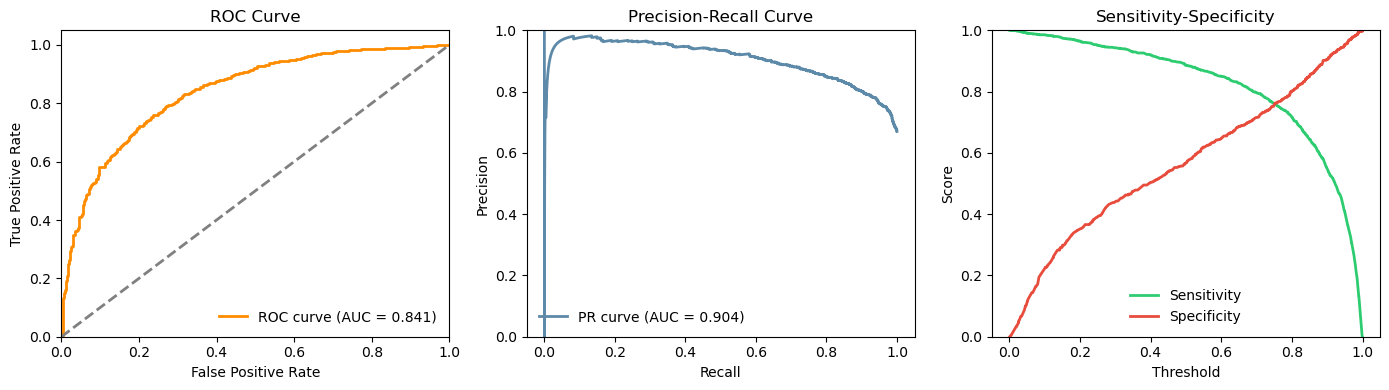

In [65]:
# Split features and target
X = sub.drop(columns=[label_col])

# Convert categorical columns to codes and scale numeric features
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.pipeline import Pipeline


categorical_features = X.select_dtypes(include=['category']).columns
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OrdinalEncoder(), categorical_features)
    ])

y = sub[label_col].map(cl_dict)

# Split into train and test sets with stratification
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.1, random_state=42, stratify=y
)

# Create XGBoost pipeline with preprocessing
from xgboost import XGBClassifier
xgb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(
        n_estimators=500,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        n_jobs=-1,
        random_state=42
    ))
])

# Fit model
xgb_pipeline.fit(X_train, y_train)

# Make predictions
y_pred = xgb_pipeline.predict(X_test)
y_pred_proba = xgb_pipeline.predict_proba(X_test)[:,1]

# Print classification report
from sklearn.metrics import classification_report, roc_curve, auc, precision_recall_curve
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Get feature importance (need to get classifier from pipeline)
xgb_clf = xgb_pipeline.named_steps['classifier']
importance = pd.DataFrame({
    'feature': X.columns,
    'importance': xgb_clf.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 20 Most Important Features:")
print(importance.head(20))

# Create figure with subplots for ROC, PR, and sensitivity/specificity curves
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(14, 4))

# Plot ROC curve
fpr, tpr, thresholds_roc = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

ax1.plot(fpr, tpr, color='darkorange', lw=2, 
         label=f'ROC curve (AUC = {roc_auc:.3f})')
ax1.plot([0, 1], [0, 1], color='grey', lw=2, linestyle='--')
ax1.set_xlim([0.0, 1.0])
ax1.set_ylim([0.0, 1.05])
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.set_title('ROC Curve')
ax1.legend(loc="lower right", frameon=False)

# Plot Precision-Recall curve
precision, recall, thresholds_pr = precision_recall_curve(y_test, y_pred_proba)
pr_auc = auc(recall, precision)

ax2.plot(recall, precision, color='#5d8aa8', lw=2,
         label=f'PR curve (AUC = {pr_auc:.3f})')
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.set_title('Precision-Recall Curve')
ax2.set_ylim([0.0, 1.0])
ax2.legend(loc="lower left", frameon=False)

# Plot Sensitivity-Specificity vs Threshold
sensitivity = tpr
specificity = 1 - fpr

ax3.plot(thresholds_roc, sensitivity, color='#2ecc71', lw=2, label='Sensitivity')
ax3.plot(thresholds_roc, specificity, color='#e74c3c', lw=2, label='Specificity')
ax3.set_xlabel('Threshold')
ax3.set_ylabel('Score')
ax3.set_title('Sensitivity-Specificity')
ax3.set_ylim([0.0, 1.0])
ax3.legend(loc="lower center", frameon=False)

plt.tight_layout()
plt.show()
#plt.savefig('pta_cls_metrics.pdf', dpi=300, bbox_inches='tight', transparent=True)


In [66]:
from sklearn.metrics import confusion_matrix
# Calculate metrics at different thresholds
thresholds = np.arange(0, 1.01, 0.01)
metrics = []

for threshold in thresholds:
    y_pred = (y_pred_proba >= threshold).astype(int)
    
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    
    # Calculate metrics
    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    f1 = 2 * (precision * sensitivity) / (precision + sensitivity) if (precision + sensitivity) > 0 else 0
    accuracy = (tp + tn) / (tp + tn + fp + fn)
    
    metrics.append({
        'Threshold': threshold,
        'Sensitivity': sensitivity,
        'Specificity': specificity, 
        'Precision': precision,
        'F1': f1,
        'Accuracy': accuracy,
        'TP': tp,
        'TN': tn,
        'FP': fp,
        'FN': fn
    })

# Create metrics dataframe
metrics_df = pd.DataFrame(metrics)

# Display metrics table
print("\nMetrics at different thresholds:")
print(metrics_df.round(3).to_string(index=False))



Metrics at different thresholds:
 Threshold  Sensitivity  Specificity  Precision    F1  Accuracy   TP  TN  FP   FN
      0.00        1.000        0.000      0.670 0.803     0.670 1245   0 612    0
      0.01        0.999        0.015      0.674 0.805     0.675 1244   9 603    1
      0.02        0.998        0.033      0.677 0.807     0.680 1243  20 592    2
      0.03        0.996        0.060      0.683 0.810     0.688 1240  37 575    5
      0.04        0.994        0.080      0.687 0.812     0.693 1237  49 563    8
      0.05        0.991        0.114      0.695 0.817     0.702 1234  70 542   11
      0.06        0.990        0.127      0.698 0.818     0.705 1232  78 534   13
      0.07        0.988        0.157      0.704 0.822     0.714 1230  96 516   15
      0.08        0.987        0.172      0.708 0.825     0.718 1229 105 507   16
      0.09        0.986        0.201      0.715 0.829     0.727 1227 123 489   18
      0.10        0.986        0.224      0.721 0.833     0.735 

In [ ]:
#metrics_df.to_csv('results/v3_cls_metrics.csv', index=False)


In [67]:
def prepare_data_for_prediction(data: pd.DataFrame,) -> pd.DataFrame: 
    """
    Prepare dataframe for machine learning by extracting sequence context features
    and converting object columns to category dtype.
    
    Args:
        data (pd.DataFrame): Input dataframe containing variant data
        
    Returns:
        pd.DataFrame: Processed dataframe with sequence context features
    """
    # Select relevant columns
    cols = cls_cols[:-1] #["CHROM", "POS", "REF", "ALT", "QUAL", "TRANSITION", "PTA_REPLISEQ", "PTA_STRAND", "PTA_GENEBODY", "PTA_20bpCONTEXTwithREF", "PTA_ALLELICIMBALANCE", "PTA_SIMPLEREPEAT"]
    df = data[cols].copy()
    
    # Extract sequence context features
    #df['TRINUCLEOTIDE_CONTEXT'] = df['PTA_20bpCONTEXTwithREF'].str[9:12]
    df['TRINUCLEOTIDE_CONTEXT'] = df.apply(trinucleotide_context, axis=1)
    df['FIVE_PRIME_CONTEXT'] = df['PTA_20bpCONTEXTwithREF'].str[:10]
    df['THREE_PRIME_CONTEXT'] = df['PTA_20bpCONTEXTwithREF'].str[-10:]
    df.drop(columns=['PTA_20bpCONTEXTwithREF'], inplace=True)
    df['PTA_SIMPLEREPEAT'] = df['PTA_SIMPLEREPEAT'].astype(str).str.split(',').str[0].str.split('.').str[0].replace('nan', 0).astype('int64')
    df['PTA_GENEBODY'] = df['PTA_GENEBODY'].astype(str).str.split(',').str[0].astype(float).astype('int64')
    # Split context sequences into individual positions
    for i in range(10):
        df[f'FIVE_PRIME_{i+1}'] = df['FIVE_PRIME_CONTEXT'].str[i].replace('N', np.random.choice(['A','T','C','G']))
        df[f'THREE_PRIME_{i+1}'] = df['THREE_PRIME_CONTEXT'].str[i].replace('N', np.random.choice(['A','T','C','G']))
    # Replace "A,D" with "A" in PTA_REDI column
    #df['PTA_REDI'] = df['PTA_REDI'].replace('A,D', 'A')

    # Drop original context columns
    df.drop(columns=['FIVE_PRIME_CONTEXT', 'THREE_PRIME_CONTEXT', "CHROM", "POS", "REF", "ALT",], inplace=True)
    
    # Convert object columns to category dtype
    object_columns = df.select_dtypes(include=['object']).columns
    df[object_columns] = df[object_columns].astype('category')
    
    return df


In [68]:
#eso29_data = pd.read_csv('feat/pred/eso29-feat.table', sep="\t", usecols=cls_cols[:-1])
my_data = pd.read_csv('/gpfs/commons/groups/landau_lab/ResolveOME/StartDir/cu08/manual_collate/sequoia/myselectedvars.snvswithsingletons.LR.4classifier.table', sep="\t", usecols=cls_cols[:-1])

pos_data = my_data[['CHROM', 'POS', 'REF', 'ALT']]


/scratch/ipykernel_74708/3241879391.py:2: DtypeWarning: Columns (172,174) have mixed types. Specify dtype option on import or set low_memory=False.
  my_data = pd.read_csv('/gpfs/commons/groups/landau_lab/ResolveOME/StartDir/cu08/manual_collate/sequoia/myselectedvars.snvswithsingletons.LR.4classifier.table', sep="\t", usecols=cls_cols[:-1])


In [69]:
my_data = prepare_data_for_prediction(my_data)

In [70]:
my_data.head()
#eso29_data.shape


,QUAL,TRANSITION,PTA_GENEBODY,PTA_STRAND,PTA_SIMPLEREPEAT,PTA_REPLISEQ,PTA_MINMAD,PTA_MAXVAF,PTA_MAXALT,PTA_RNACOV,...,FIVE_PRIME_6,THREE_PRIME_6,FIVE_PRIME_7,THREE_PRIME_7,FIVE_PRIME_8,THREE_PRIME_8,FIVE_PRIME_9,THREE_PRIME_9,FIVE_PRIME_10,THREE_PRIME_10
0,21.0,1,5873,-,-9857,63.09,10000000.0,0,9,1.0,...,C,G,C,A,A,A,T,A,T,C
1,33.0,1,36595,-,-1628,61.82,10000000.0,0,15,1.0,...,A,G,G,A,G,A,C,G,A,T
2,22.0,1,28283,-,0,61.32,10000000.0,0,4,8.0,...,G,C,A,A,A,G,T,C,T,C
3,29.0,1,24363,-,853,61.02,10000000.0,0,6,2.0,...,A,G,G,C,C,G,G,G,C,A
4,35.0,1,23083,-,-331,60.94,10000000.0,0,12,32.0,...,G,C,C,A,C,G,T,G,C,G


In [71]:
# Check for 'N' values in all columns
for col in my_data.columns:
    if my_data[col].dtype == 'category' or my_data[col].dtype == 'object':
        n_rows = my_data[my_data[col] == 'N']
        if len(n_rows) > 0:
            print(f"\nRows containing 'N' in {col}:")
            print(n_rows[[col]].head())
            print(f"Total rows with 'N': {len(n_rows)}")

In [72]:
xgb_pipeline.fit(X_train, y_train)

/gpfs/commons/groups/landau_lab/tprieto/conda/classifier-env/lib/python3.10/site-packages/sklearn/utils/extmath.py:1144: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
/gpfs/commons/groups/landau_lab/tprieto/conda/classifier-env/lib/python3.10/site-packages/sklearn/utils/extmath.py:1149: RuntimeWarning: invalid value encountered in divide
  T = new_sum / new_sample_count
/gpfs/commons/groups/landau_lab/tprieto/conda/classifier-env/lib/python3.10/site-packages/sklearn/utils/extmath.py:1169: RuntimeWarning: invalid value encountered in divide
  new_unnormalized_variance -= correction**2 / new_sample_count


,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [73]:
# Load and preprocess eso29 data
#my_data = pd.read_csv('data/cu01.prod.table', sep="\t", usecols=cls_cols)

# Apply same preprocessing as training data
#my_data = my_data[~my_data['CHROM'].isin(['chrX', 'chr22'])]


# Make predictions using trained model
my_pred = xgb_pipeline.predict(my_data)
my_pred_proba = xgb_pipeline.predict_proba(my_data)[:,1]

# Add predictions to dataframe
my_data['predicted_class'] = my_pred
my_data['prediction_probability'] = my_pred_proba

print("\nPredictions for dataset:")
print(f"Total variants: {len(my_data)}")
print(f"Predicted positive variants: {sum(my_pred)}")
print(f"Percentage positive: {(sum(my_pred)/len(my_pred)*100):.1f}%")



Predictions for eso29 dataset:
Total variants: 1378522
Predicted positive variants: 1011443
Percentage positive: 73.4%


In [74]:
my_data

,QUAL,TRANSITION,PTA_GENEBODY,PTA_STRAND,PTA_SIMPLEREPEAT,PTA_REPLISEQ,PTA_MINMAD,PTA_MAXVAF,PTA_MAXALT,PTA_RNACOV,...,FIVE_PRIME_7,THREE_PRIME_7,FIVE_PRIME_8,THREE_PRIME_8,FIVE_PRIME_9,THREE_PRIME_9,FIVE_PRIME_10,THREE_PRIME_10,predicted_class,prediction_probability
0,21.0,1,5873,-,-9857,63.09,10000000.0,0,9,1.0,...,C,A,A,A,T,A,T,C,1,0.996911
1,33.0,1,36595,-,-1628,61.82,10000000.0,0,15,1.0,...,G,A,G,A,C,G,A,T,1,0.969343
2,22.0,1,28283,-,0,61.32,10000000.0,0,4,8.0,...,A,A,A,G,T,C,T,C,0,0.485157
3,29.0,1,24363,-,853,61.02,10000000.0,0,6,2.0,...,G,C,C,G,G,G,C,A,1,0.954266
4,35.0,1,23083,-,-331,60.94,10000000.0,0,12,32.0,...,C,A,C,G,T,G,C,G,1,0.878837
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1378517,25.0,0,-689952,-,24,NaN,10000000.0,0,18,2.0,...,A,G,A,T,T,G,G,G,1,0.600410
1378518,25.0,1,-693318,-,52,NaN,10000000.0,0,4,1.0,...,T,C,T,A,A,A,A,A,1,0.954598
1378519,25.0,0,-30858791,-,0,NaN,10000000.0,0,50,NaN,...,T,T,T,C,C,C,C,A,0,0.466334
1378520,44.0,1,-30859747,-,0,NaN,10000000.0,0,43,NaN,...,A,T,T,T,T,C,C,C,0,0.427784


In [ ]:
#eso29_data['TRINUCLEOTIDE_CONTEXT'].value_counts().sort_index().to_csv('eso29_all_sig.tsv', sep='\t')

In [ ]:
#eso29_data[eso29_data['predicted_class'] == 1]['TRINUCLEOTIDE_CONTEXT'].value_counts().sort_index().to_csv('eso29_fp_sig.tsv', sep='\t')
#eso29_data[eso29_data['predicted_class'] == 0]['TRINUCLEOTIDE_CONTEXT'].value_counts().sort_index().to_csv('eso29_tp_sig.tsv', sep='\t')

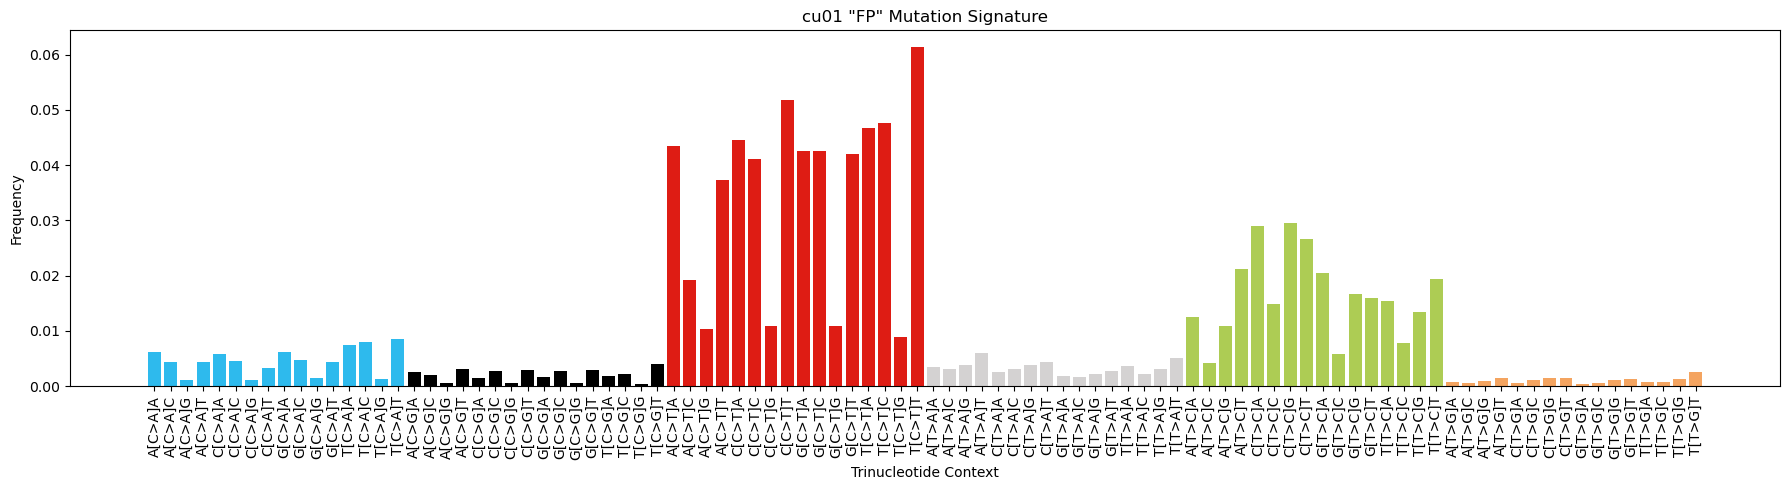

In [78]:
#Predicted class based on probability of error
eso_sig = my_data[my_data['predicted_class'] == 1]['TRINUCLEOTIDE_CONTEXT'].value_counts(normalize=True).sort_index()
plot_mutation_signature(eso_sig, title='cu01 "FP" Mutation Signature')



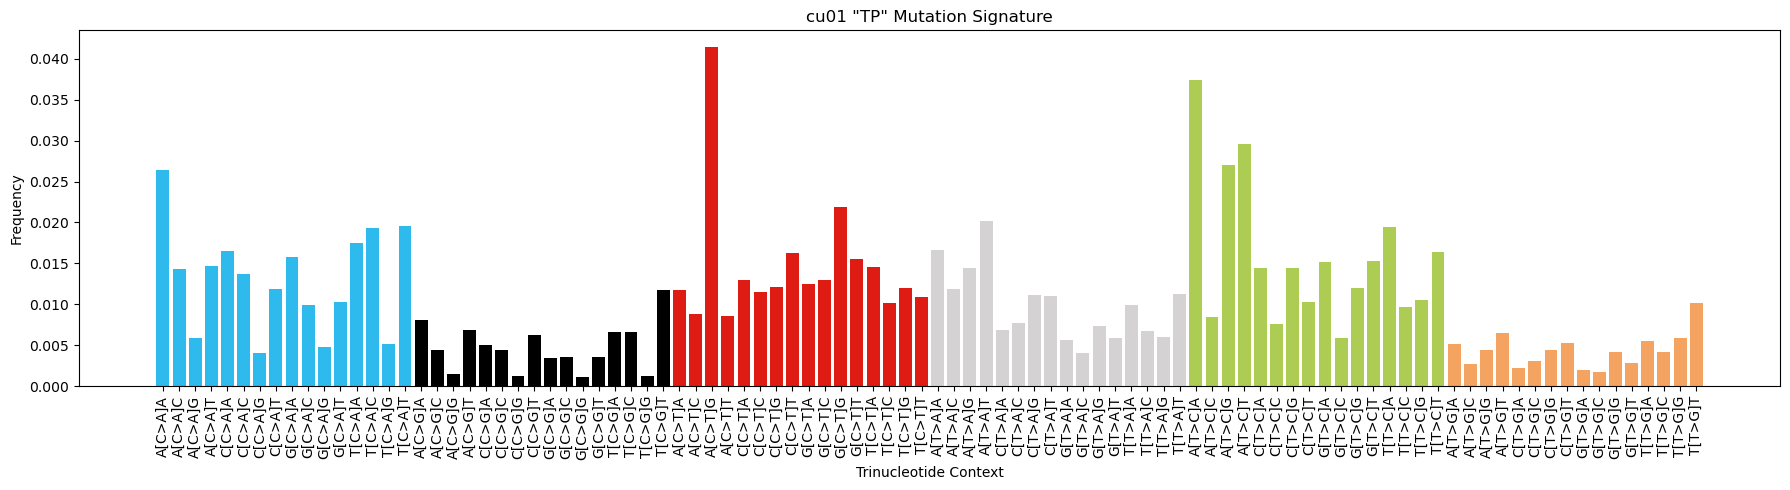

In [79]:
eso_sig = my_data[my_data['predicted_class'] == 0]['TRINUCLEOTIDE_CONTEXT'].value_counts(normalize=True).sort_index()
plot_mutation_signature(eso_sig, title='cu01 "TP" Mutation Signature')



In [80]:
# Calculate cosine similarity between FP signature and eso29 signature
cos_sim = np.dot(fp_sig, eso_sig) / (np.linalg.norm(fp_sig) * np.linalg.norm(eso_sig))

print(f"\nCosine similarity between FP and my TP signatures: {cos_sim:.3f}")



Cosine similarity between FP and my TP signatures: 0.526


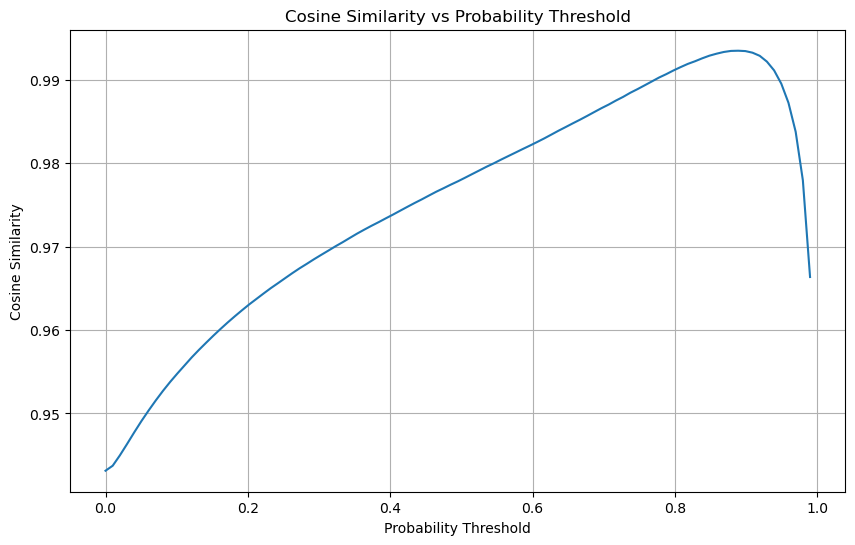


Maximum cosine similarity: 0.994
At threshold: 0.89


In [81]:
def sig_at_prob(data, prob, invert=False):
    if invert:
        return data[data['prediction_probability'] < prob]['TRINUCLEOTIDE_CONTEXT'].value_counts(normalize=True).sort_index()
    else:
        return data[data['prediction_probability'] > prob]['TRINUCLEOTIDE_CONTEXT'].value_counts(normalize=True).sort_index()

# Calculate cosine similarity at different probability thresholds
thresholds = np.linspace(0, 1, 100)
similarities = []

for thresh in thresholds:
    sig = sig_at_prob(my_data, thresh)
    if len(sig) > 0:  # Only calculate if we have variants above threshold
        cos_sim = np.dot(fp_sig, sig) / (np.linalg.norm(fp_sig) * np.linalg.norm(sig))
        similarities.append(cos_sim)
    else:
        similarities.append(0)

# Plot results
plt.figure(figsize=(10,6))
plt.plot(thresholds, similarities)
plt.xlabel('Probability Threshold')
plt.ylabel('Cosine Similarity')
plt.title('Cosine Similarity vs Probability Threshold')
plt.grid(True)
plt.show()

# Print the maximum similarity and its threshold
max_sim_idx = np.argmax([s for s in similarities if not np.isnan(s)])
max_sim = [s for s in similarities if not np.isnan(s)][max_sim_idx]
print(f"\nMaximum cosine similarity: {max_sim:.3f}")
print(f"At threshold: {thresholds[max_sim_idx]:.2f}")


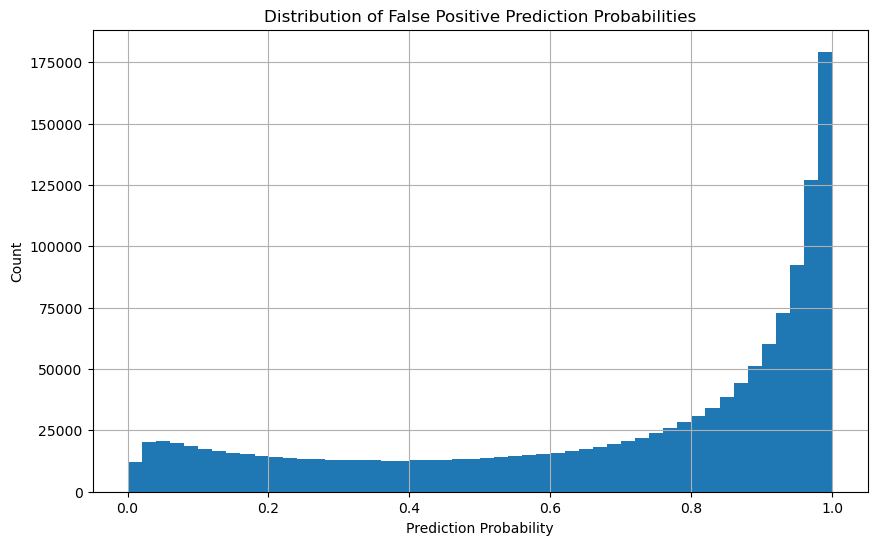

In [82]:
plt.figure(figsize=(10,6))
plt.hist(my_data['prediction_probability'], bins=50)
plt.xlabel('Prediction Probability')
plt.ylabel('Count')
plt.title('Distribution of False Positive Prediction Probabilities')
plt.grid(True)
plt.show()


In [83]:
my_data['prediction_at_best_cosine_similarity'] = (my_data['prediction_probability'] > thresholds[max_sim_idx]).astype(int)


In [ ]:
#eso29_data[eso29_data['prediction_at_best_cosine_similarity'] == 1]['TRINUCLEOTIDE_CONTEXT'].value_counts().sort_index().to_csv('eso29_fp_sig.tsv', sep='\t')
#eso29_data[eso29_data['prediction_at_best_cosine_similarity'] == 0]['TRINUCLEOTIDE_CONTEXT'].value_counts().sort_index().to_csv('eso29_tp_sig.tsv', sep='\t')

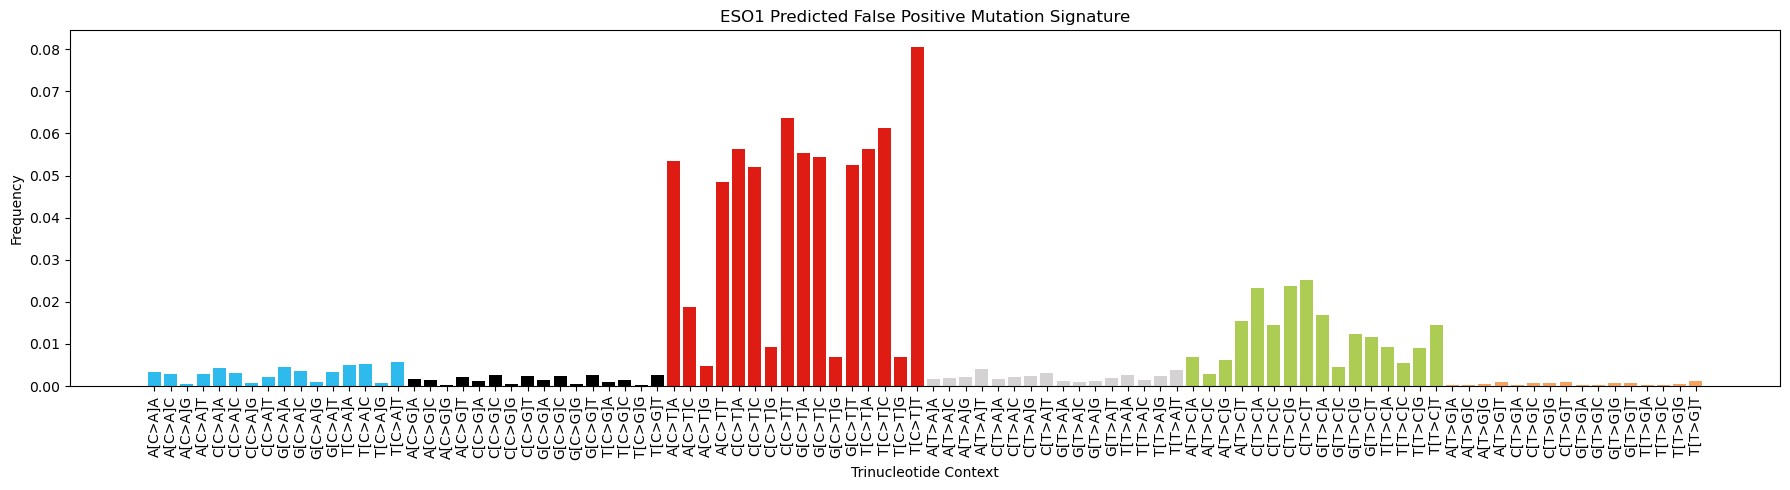

In [84]:
# Get signature at best cosine similarity threshold
best_sig = sig_at_prob(my_data, thresholds[max_sim_idx])

plot_mutation_signature(best_sig, title='ESO1 Predicted False Positive Mutation Signature', save_path='eso29_fp_sig.pdf')


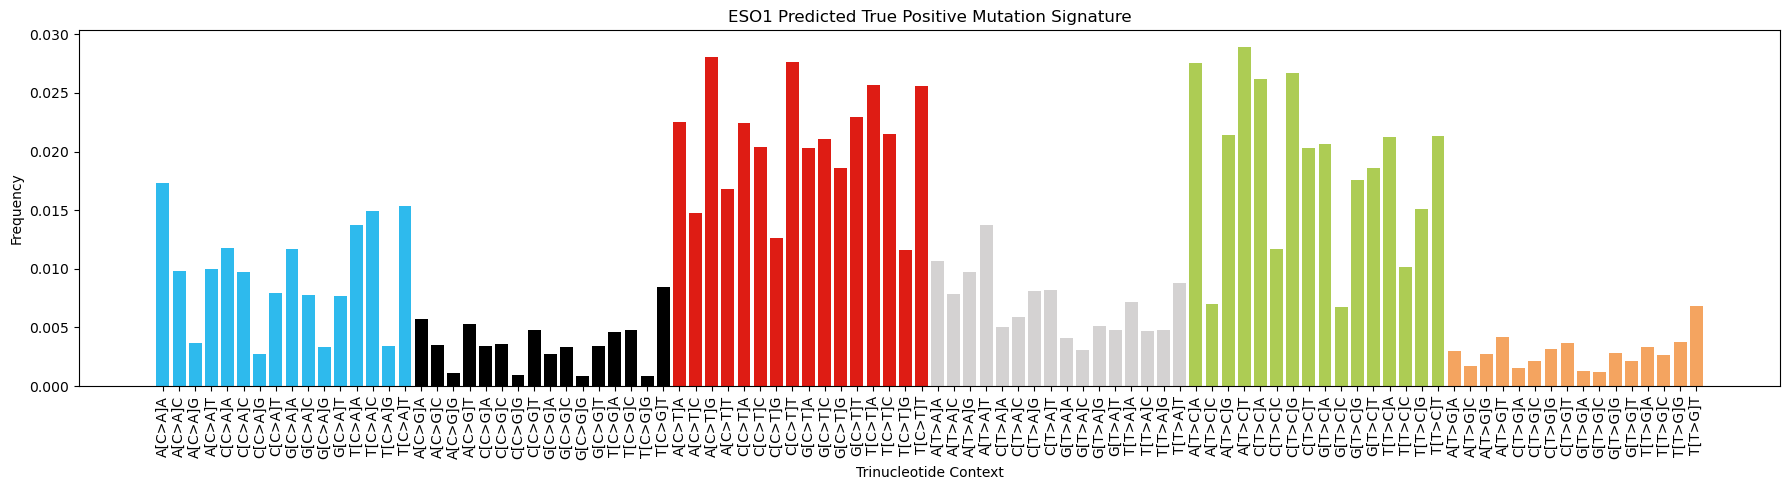

In [85]:
# Get signature at best cosine similarity threshold
best_sig = sig_at_prob(my_data, thresholds[max_sim_idx], invert=True)

plot_mutation_signature(best_sig, title='ESO1 Predicted True Positive Mutation Signature', save_path='eso29_tp_sig.pdf')


In [86]:
my_data

,QUAL,TRANSITION,PTA_GENEBODY,PTA_STRAND,PTA_SIMPLEREPEAT,PTA_REPLISEQ,PTA_MINMAD,PTA_MAXVAF,PTA_MAXALT,PTA_RNACOV,...,THREE_PRIME_7,FIVE_PRIME_8,THREE_PRIME_8,FIVE_PRIME_9,THREE_PRIME_9,FIVE_PRIME_10,THREE_PRIME_10,predicted_class,prediction_probability,prediction_at_best_cosine_similarity
0,21.0,1,5873,-,-9857,63.09,10000000.0,0,9,1.0,...,A,A,A,T,A,T,C,1,0.996911,1
1,33.0,1,36595,-,-1628,61.82,10000000.0,0,15,1.0,...,A,G,A,C,G,A,T,1,0.969343,1
2,22.0,1,28283,-,0,61.32,10000000.0,0,4,8.0,...,A,A,G,T,C,T,C,0,0.485157,0
3,29.0,1,24363,-,853,61.02,10000000.0,0,6,2.0,...,C,C,G,G,G,C,A,1,0.954266,1
4,35.0,1,23083,-,-331,60.94,10000000.0,0,12,32.0,...,A,C,G,T,G,C,G,1,0.878837,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1378517,25.0,0,-689952,-,24,NaN,10000000.0,0,18,2.0,...,G,A,T,T,G,G,G,1,0.600410,0
1378518,25.0,1,-693318,-,52,NaN,10000000.0,0,4,1.0,...,C,T,A,A,A,A,A,1,0.954598,1
1378519,25.0,0,-30858791,-,0,NaN,10000000.0,0,50,NaN,...,T,T,C,C,C,C,A,0,0.466334,0
1378520,44.0,1,-30859747,-,0,NaN,10000000.0,0,43,NaN,...,T,T,T,T,C,C,C,0,0.427784,0


In [87]:
my_data['prediction_at_best_cosine_similarity'].value_counts(normalize=True)


prediction_at_best_cosine_similarity
0    0.593262
1    0.406738
Name: proportion, dtype: float64

In [88]:
# Add back CHROM and POS columns from original data
my_data = pd.concat([pos_data[['CHROM', 'POS', 'REF', 'ALT']], my_data], axis=1)


# Save the results to a file
## Warning: the line below will overwrite the file

In [89]:
my_data.drop(columns=[col for col in my_data.columns if 'PRIME' in col]).to_csv('/gpfs/commons/groups/landau_lab/ResolveOME/StartDir/classifier/cu08_v3_predictions.csv.gz', index=False)

In [90]:
{
    'predicted_class': 'Raw prediction from model (0=real, 1=false positive, 0.5 cutoff)',
    'prediction_probability': 'Probability of being a false positive variant',
    'prediction_at_best_cosine_similarity': 'Prediction using threshold that maximizes cosine similarity with known false positives from training'
}


{'predicted_class': 'Raw prediction from model (0=real, 1=false positive, 0.5 cutoff)',
 'prediction_probability': 'Probability of being a false positive variant',
 'prediction_at_best_cosine_similarity': 'Prediction using threshold that maximizes cosine similarity with known false positives from training'}